<a href="https://colab.research.google.com/github/Geco-ta/Machine-Vision/blob/main/MLAquanet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Tue Jun 16 21:57:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.7 MB/s eta 0:00:00


In [ ]:
import os
import yaml
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

import torch
print("Torch version :", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
print("GPU :", torch.cuda.get_device_name(0))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch version : 2.11.0+cu128
CUDA available : True
GPU : Tesla T4


In [ ]:
zip_path = "/content/aqua_net 2.yolov8.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak.")

Dataset berhasil diekstrak.


In [ ]:
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f'{indent}{os.path.basename(root)}/')

    subindent = ' ' * 4 * (level + 1)

    for f in files[:5]:
        print(f'{subindent}{f}')

dataset/
    README.dataset.txt
    README.roboflow.txt
    data.yaml
    valid/
        labels/
            frame0-02-32-00_jpg.rf.AmuhPmQmy0fDXfU6adkM.txt
            1145_jpg.rf.328TzfcXspSxTpo38eyx.txt
            1610_jpg.rf.fpmizkWmpru0C9wuyXsB.txt
            797_jpg.rf.Nn2HppFhAmXcKjCYZLGS.txt
            frame2n (1167)_jpg.rf.u355QiES6rSZZSTZPMsM.txt
        images/
            frame0-07-53-00_jpg.rf.i3ZjVQ5WD8cYbcKB7tWY.jpg
            frame2n (1224)_jpg.rf.VPNrzHEmAFoojvD04lt1.jpg
            frame0-16-03-00_jpg.rf.XUg2dpkMceZiWXPi71Y1.jpg
            frame1n (510)_jpg.rf.5Tg1nRp3tMqxgi3o4mVn.jpg
            1502_jpg.rf.qZGug4NhjSv7EkoigG3v.jpg
    test/
        labels/
            frame0-04-07-50_jpg.rf.tVeWKWEGEBcJDpwZkP54.txt
            482_jpg.rf.LgsymDbF4yrgnJYTfP4E.txt
            frame1n (244)_jpg.rf.IsGNuGLVw2eyhfrmBZUB.txt
            2196_jpg.rf.pWpxGeB9pKVShc8mVlwT.txt
            frame1n (316)_jpg.rf.7ic6hPUcH20mlE3WyMWI.txt
        images/
            frame0-09

In [ ]:
yaml_path = None

for root, dirs, files in os.walk(extract_path):
    if "data.yaml" in files:
        yaml_path = os.path.join(root, "data.yaml")
        break

print("Lokasi data.yaml:")
print(yaml_path)

Lokasi data.yaml:
/content/dataset/data.yaml


In [ ]:
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

print("Isi data.yaml:")
print(data_config)

Isi data.yaml:
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 3, 'names': ['biofouling', 'hole', 'vegetation'], 'roboflow': {'workspace': 'ndok-sen', 'project': 'aqua_net-2-s9ihs', 'version': 'dataset', 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/ndok-sen/aqua_net-2-s9ihs/dataset/dataset'}}


In [ ]:
print("Jumlah kelas :", data_config['nc'])

print("\nNama kelas:")

for i, name in enumerate(data_config['names']):
    print(f"{i} : {name}")

Jumlah kelas : 3

Nama kelas:
0 : biofouling
1 : hole
2 : vegetation


In [ ]:
def count_images(folder):
    exts = ('.jpg', '.jpeg', '.png')
    return len([
        f for f in os.listdir(folder)
        if f.lower().endswith(exts)
    ])

base_path = os.path.dirname(yaml_path)

train_img = os.path.join(base_path, "train/images")
valid_img = os.path.join(base_path, "valid/images")
test_img = os.path.join(base_path, "test/images")

train_count = count_images(train_img)
valid_count = count_images(valid_img)
test_count = count_images(test_img)

print("Jumlah gambar")
print("----------------")
print("Train :", train_count)
print("Valid :", valid_count)
print("Test  :", test_count)
print("Total :", train_count+valid_count+test_count)

Jumlah gambar
----------------
Train : 5036
Valid : 1438
Test  : 720
Total : 7194


In [ ]:
assert os.path.exists(yaml_path), "data.yaml tidak ditemukan"

assert train_count > 0, "Train kosong"
assert valid_count > 0, "Valid kosong"
assert test_count > 0, "Test kosong"

print("Dataset siap digunakan untuk training.")

Dataset siap digunakan untuk training.


In [ ]:
print("data.yaml digunakan:")
print(yaml_path)

data.yaml digunakan:
/content/dataset/data.yaml


In [ ]:
model = YOLO("yolov8s.pt")

print("Model berhasil dimuat")

Model berhasil dimuat


In [ ]:
model.info()

YOLOv8s summary: 129 layers, 11,166,560 parameters, 0 gradients, 28.8 GFLOPs


(129, 11166560, 0, 28.816844800000002)

In [ ]:
results = model.train(
    data=yaml_path,
    epochs=25,
    imgsz=640,
    batch=16,
    workers=2,
    patience=20,
    device=0,
    project="YOLOv8s_aquanet",
    name="aquanet_1",
    pretrained=True,
    verbose=True
)

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=aquanet_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, pe

In [ ]:
print(results.save_dir)

/content/runs/detect/YOLOv8s_aquanet/aquanet_1


In [ ]:
import os

save_dir = results.save_dir

print(os.listdir(save_dir))

['BoxF1_curve.png', 'confusion_matrix.png', 'args.yaml', 'confusion_matrix_normalized.png', 'train_batch1.jpg', 'val_batch1_pred.jpg', 'BoxPR_curve.png', 'val_batch1_labels.jpg', 'train_batch0.jpg', 'labels.jpg', 'results.png', 'BoxP_curve.png', 'results.csv', 'train_batch4726.jpg', 'val_batch2_labels.jpg', 'train_batch2.jpg', 'train_batch4727.jpg', 'BoxR_curve.png', 'val_batch2_pred.jpg', 'weights', 'val_batch0_pred.jpg', 'val_batch0_labels.jpg', 'train_batch4725.jpg']


In [ ]:
best_model = os.path.join(save_dir, "weights", "best.pt")

print(best_model)
print(os.path.exists(best_model))

/content/runs/detect/YOLOv8s_aquanet/aquanet_1/weights/best.pt
True


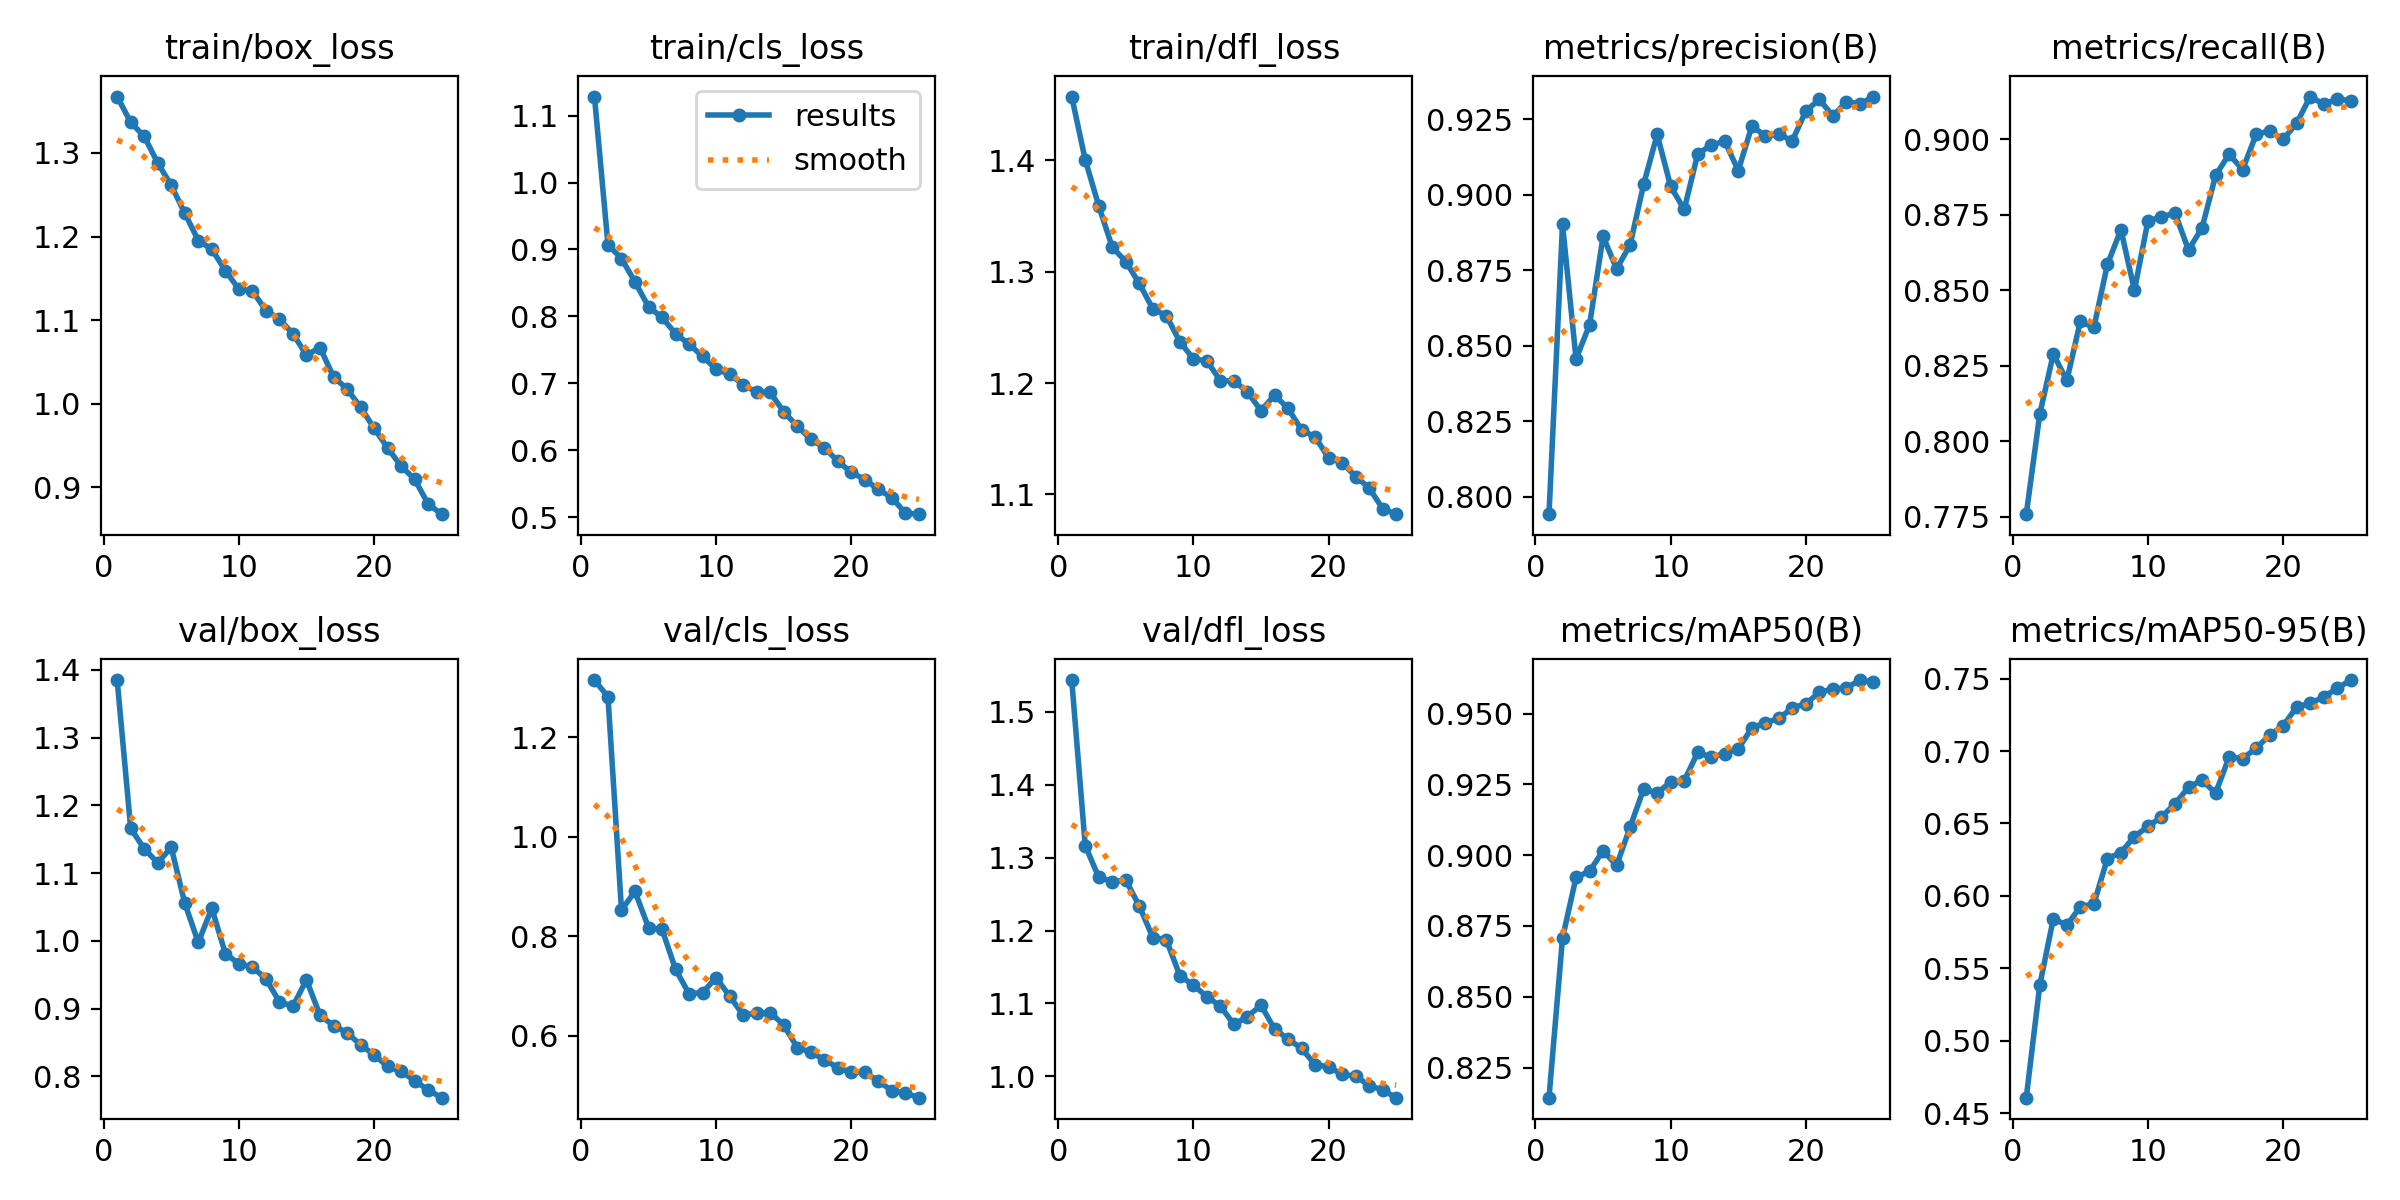

In [ ]:
from IPython.display import Image, display

results_png = os.path.join(save_dir, "results.png")

display(Image(filename=results_png))

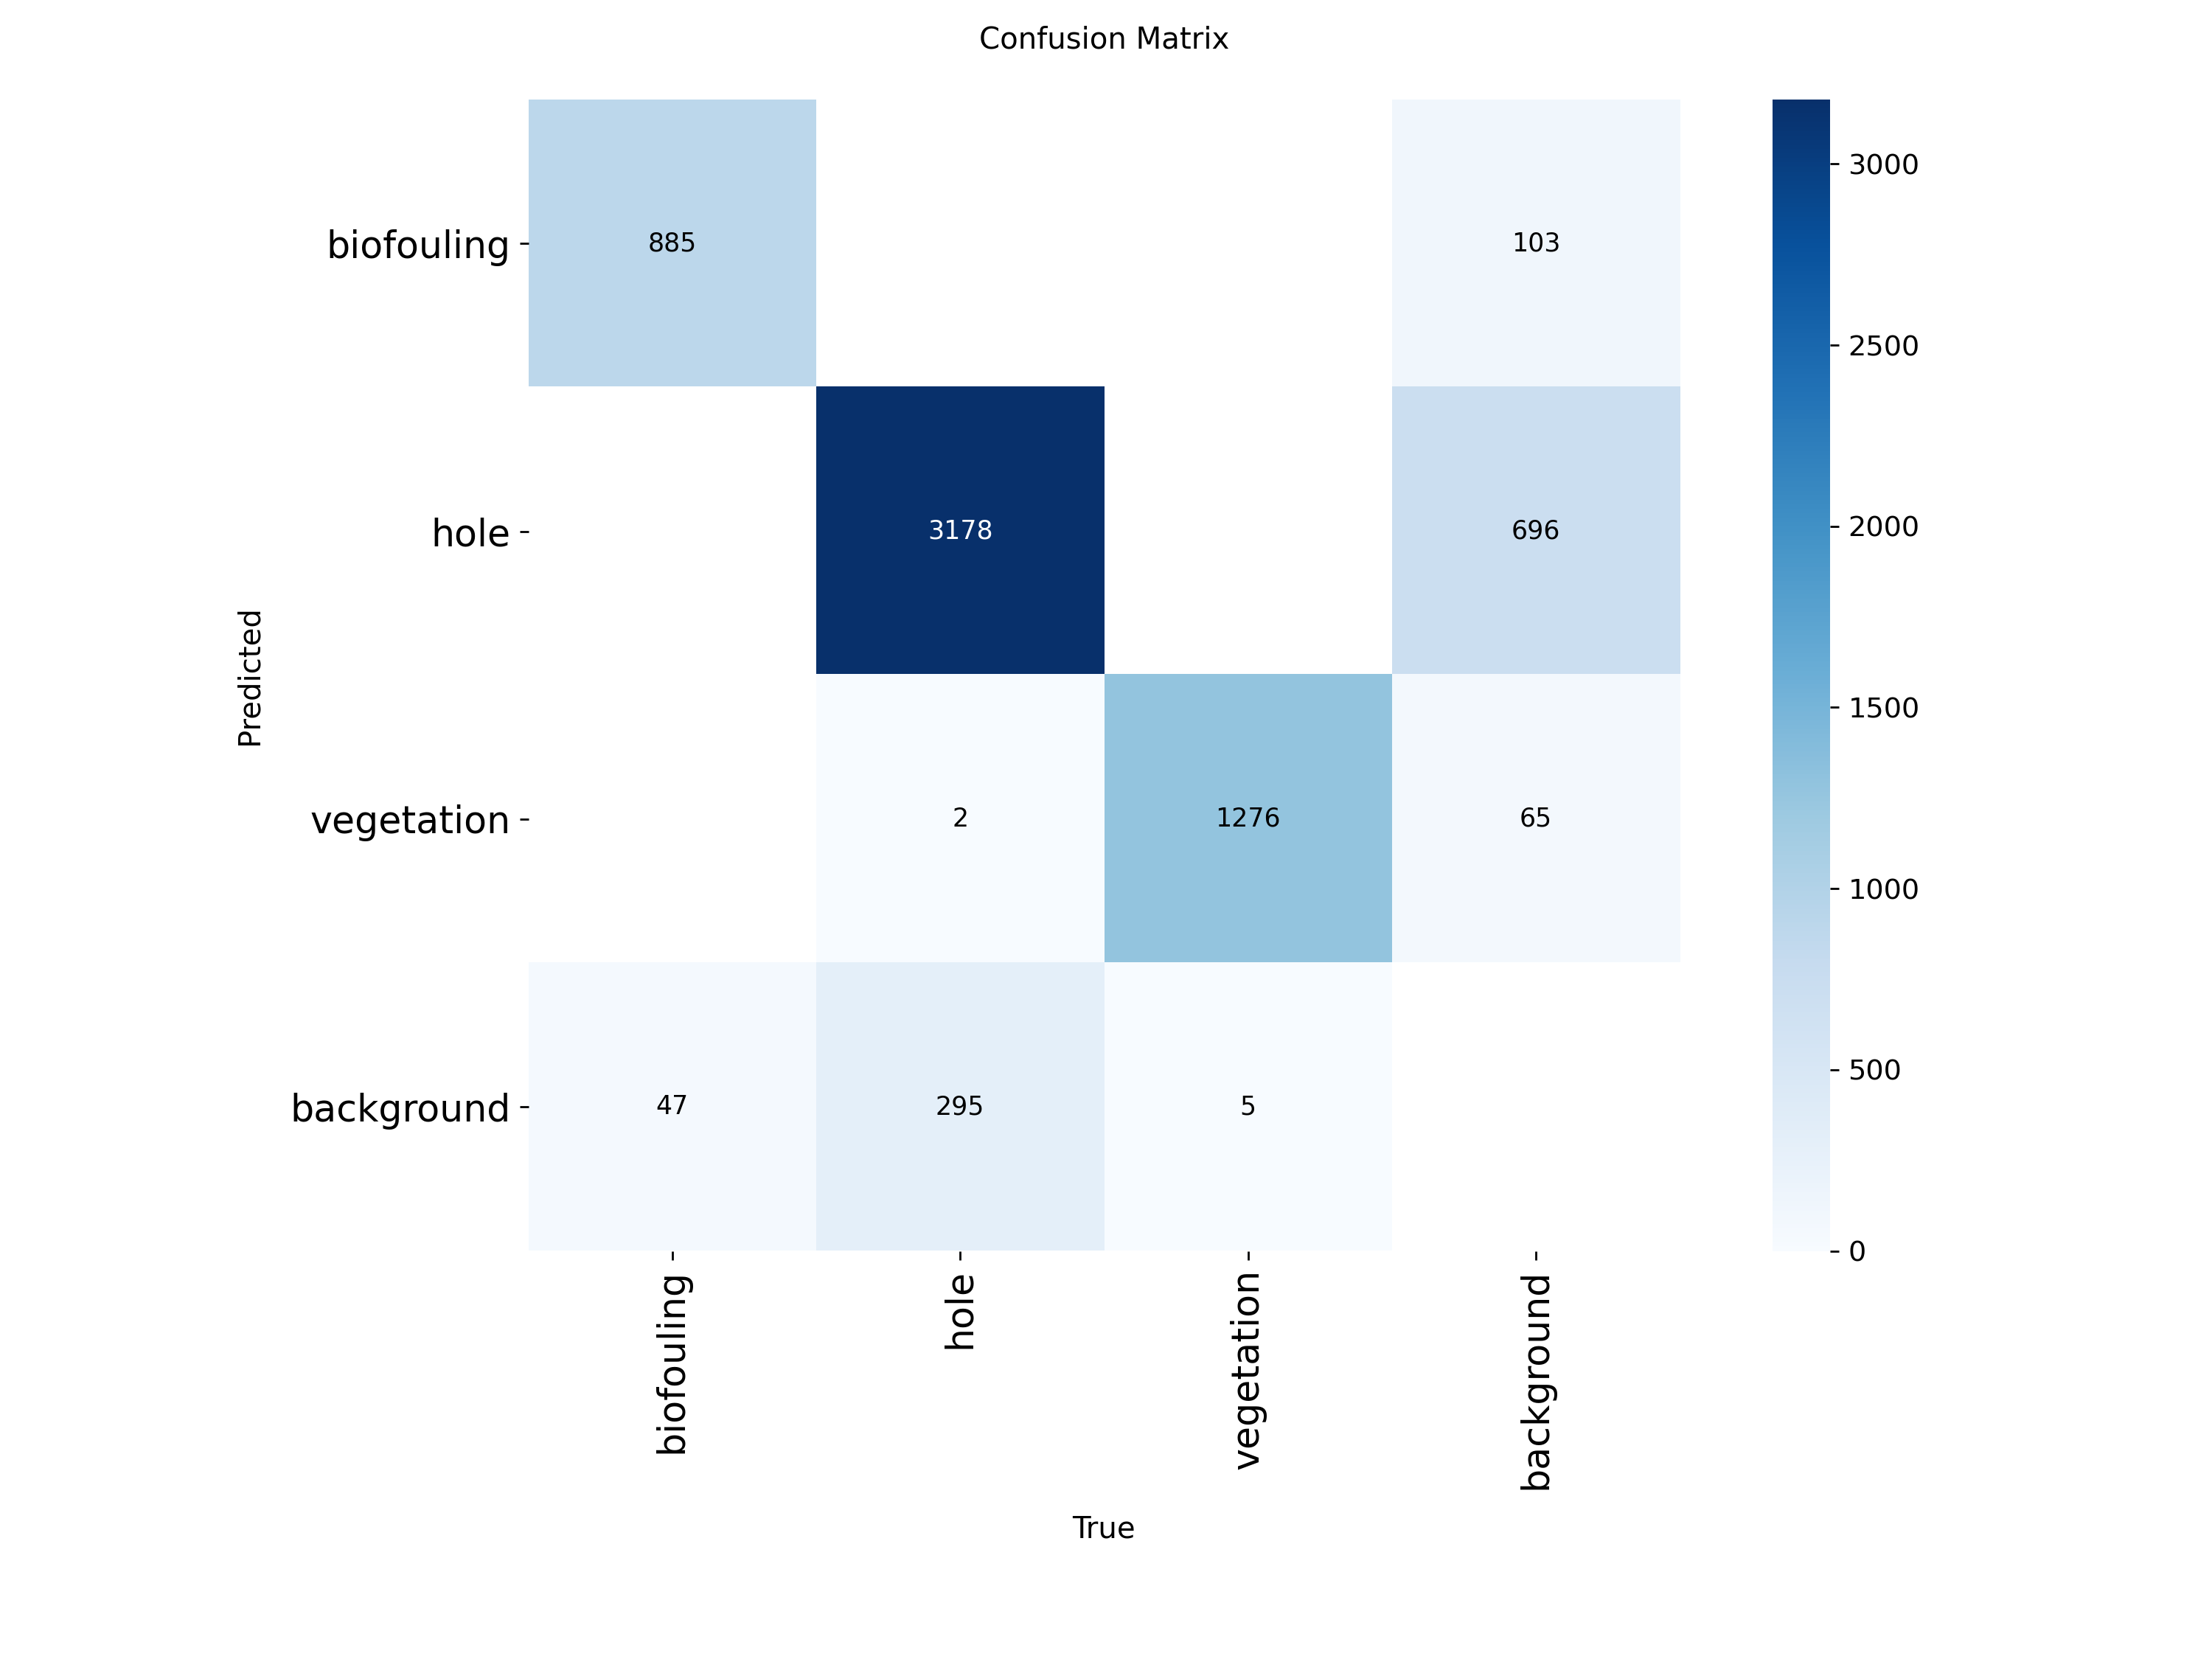

In [ ]:
conf_matrix = os.path.join(save_dir, "confusion_matrix.png")

display(Image(filename=conf_matrix))

In [ ]:
import pandas as pd

csv_path = os.path.join(save_dir, "results.csv")

df = pd.read_csv(csv_path)

df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
20,21,2848.71,0.94705,0.55657,1.12854,0.93154,0.90528,0.95750,0.73043,0.81445,0.52746,1.00252,0.000297,0.000297,0.000297
21,22,2969.73,0.92524,0.54185,1.11614,0.92600,0.91408,0.95870,0.73302,0.80710,0.50894,1.00040,0.000241,0.000241,0.000241
22,23,3092.06,0.90967,0.52937,1.10587,0.93084,0.91153,0.95900,0.73740,0.79360,0.49027,0.98734,0.000184,0.000184,0.000184
23,24,3215.65,0.87978,0.50634,1.08711,0.93001,0.91332,0.96182,0.74336,0.77972,0.48527,0.98120,0.000127,0.000127,0.000127
24,25,3337.98,0.86776,0.50489,1.08234,0.93248,0.91263,0.96109,0.74906,0.76838,0.47596,0.97073,0.000071,0.000071,0.000071


In [ ]:
best_epoch = df["metrics/mAP50(B)"].idxmax()

print("Epoch terbaik :", best_epoch + 1)

print(df.loc[
    best_epoch,
    [
        "metrics/precision(B)",
        "metrics/recall(B)",
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)"
    ]
])

Epoch terbaik : 24
metrics/precision(B)    0.93001
metrics/recall(B)       0.91332
metrics/mAP50(B)        0.96182
metrics/mAP50-95(B)     0.74336
Name: 23, dtype: float64


In [ ]:
from ultralytics import YOLO

model = YOLO(best_model)

print("Model berhasil dimuat")

Model berhasil dimuat


In [ ]:
import random
import glob

test_images = glob.glob(
    "/content/dataset/test/images/*"
)

random.seed(42)

sample_images = random.sample(test_images, 5)

sample_images

['/content/dataset/test/images/728_jpg.rf.6VezYyFgHmmi2KpGHvys.jpg',
 '/content/dataset/test/images/frame2n (1090)_jpg.rf.0StYjItN0tm1mwI23QRq.jpg',
 '/content/dataset/test/images/frame1n (522)_jpg.rf.yGZGdGQ3FCJvGaIegrai.jpg',
 '/content/dataset/test/images/kupool_frame_208 (130)_jpg.rf.Izf5L8BWb2GxeQK9ZURz.jpg',
 '/content/dataset/test/images/1155_jpg.rf.rCLAGpr3zvE9G2pKBrOK.jpg']

In [ ]:
predictions = model.predict(
    source=sample_images,
    conf=0.25,
    save=True,
    imgsz=640
)


0: 640x640 6 holes, 2 vegetations, 14.2ms
1: 640x640 1 biofouling, 14.2ms
2: 640x640 1 biofouling, 14.2ms
3: 640x640 1 vegetation, 14.2ms
4: 640x640 6 holes, 1 vegetation, 14.2ms
Speed: 3.9ms preprocess, 14.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


In [ ]:
hasil_prediksi = predictions[0].save_dir

print("Folder hasil:")
print(hasil_prediksi)

Folder hasil:
/content/runs/detect/predict


In [ ]:
predicted_images = glob.glob(
    os.path.join(hasil_prediksi, "*")
)

predicted_images.sort()

predicted_images

['/content/runs/detect/predict/image0.jpg',
 '/content/runs/detect/predict/image1.jpg',
 '/content/runs/detect/predict/image2.jpg',
 '/content/runs/detect/predict/image3.jpg',
 '/content/runs/detect/predict/image4.jpg']

image0.jpg


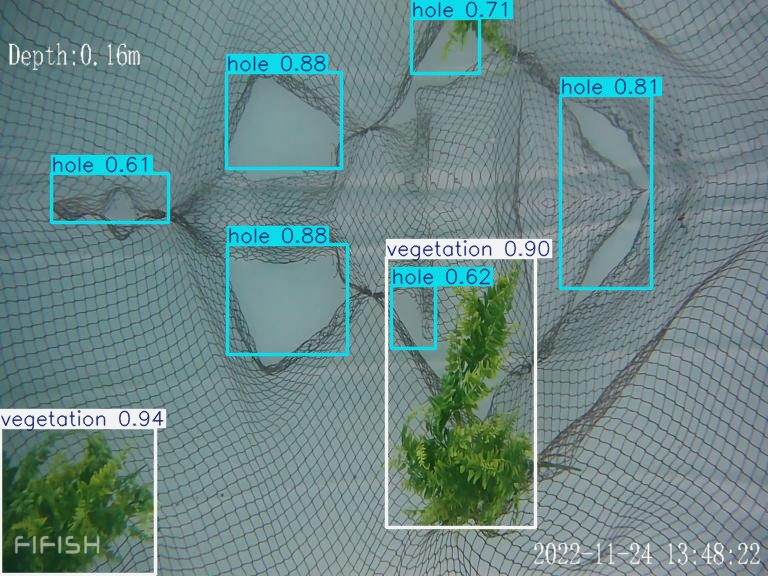

------------------------------------------------------------
image1.jpg


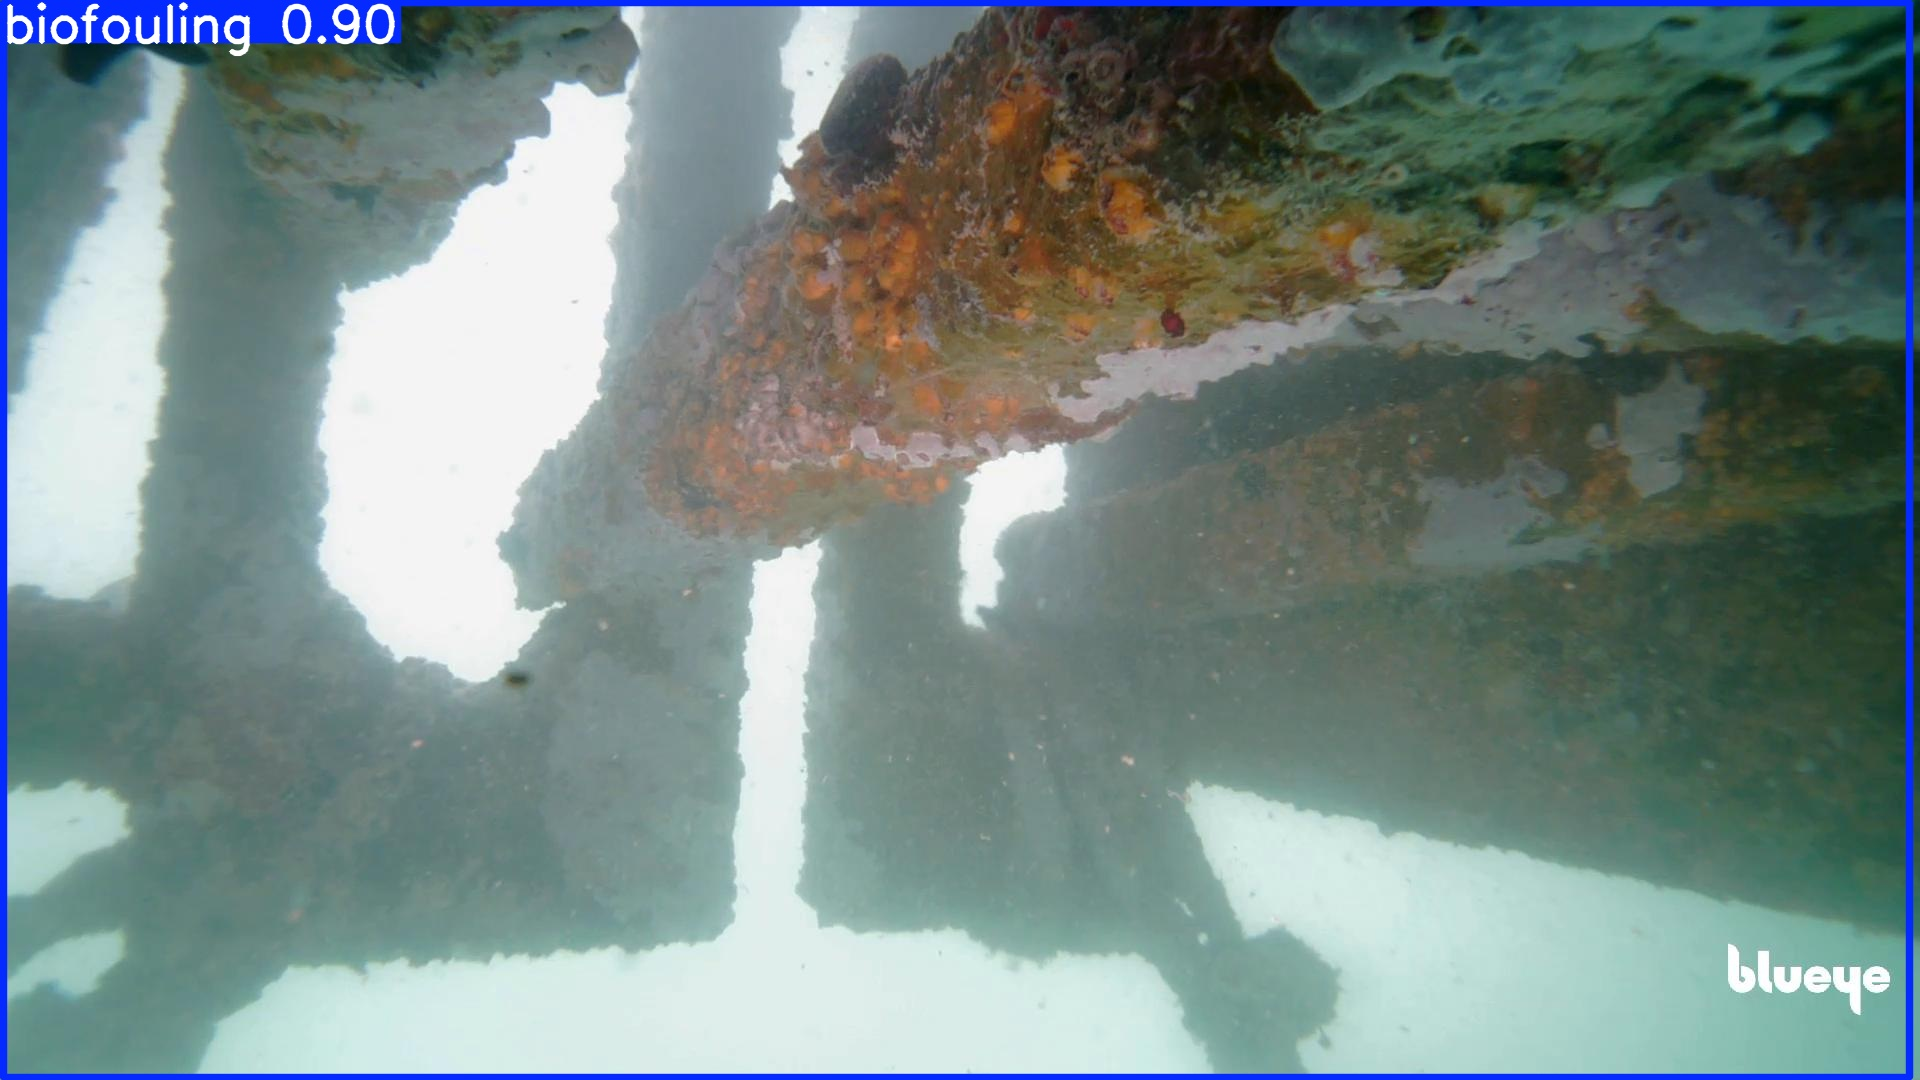

------------------------------------------------------------
image2.jpg


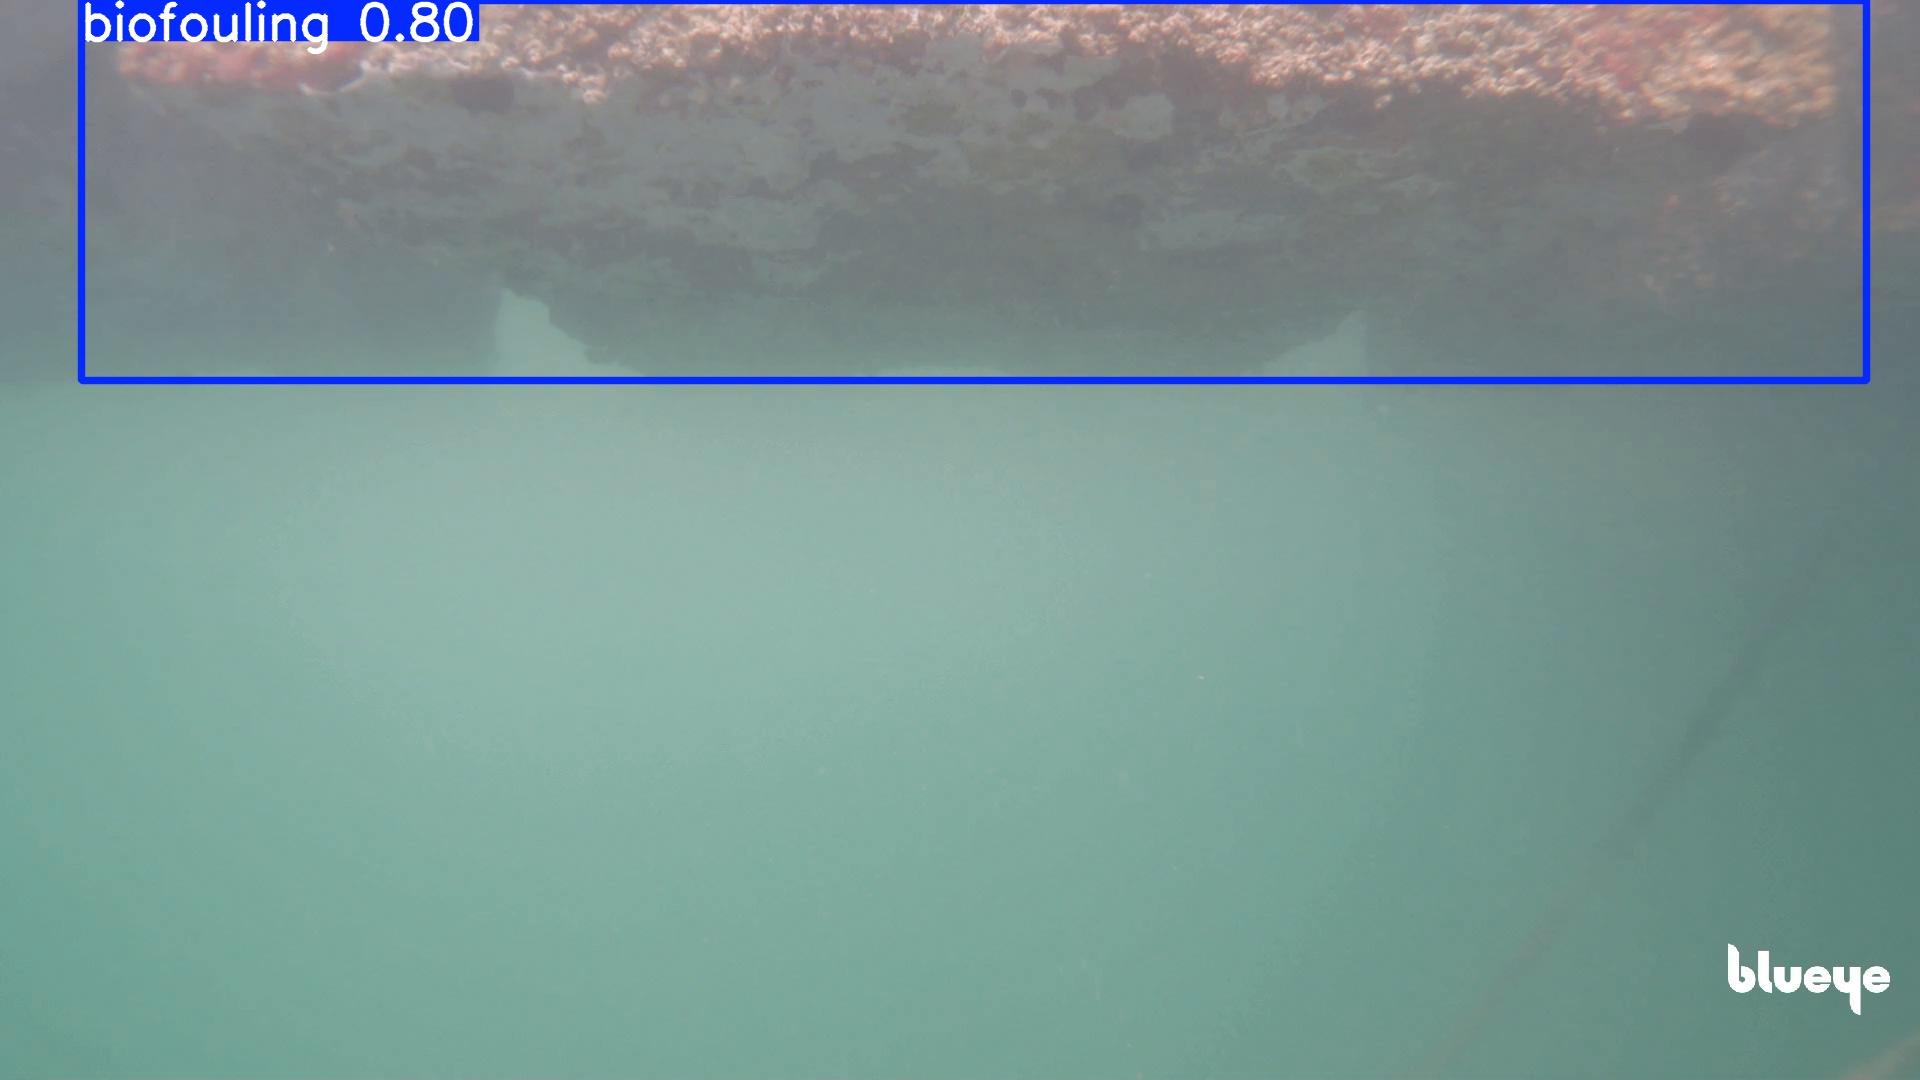

------------------------------------------------------------
image3.jpg


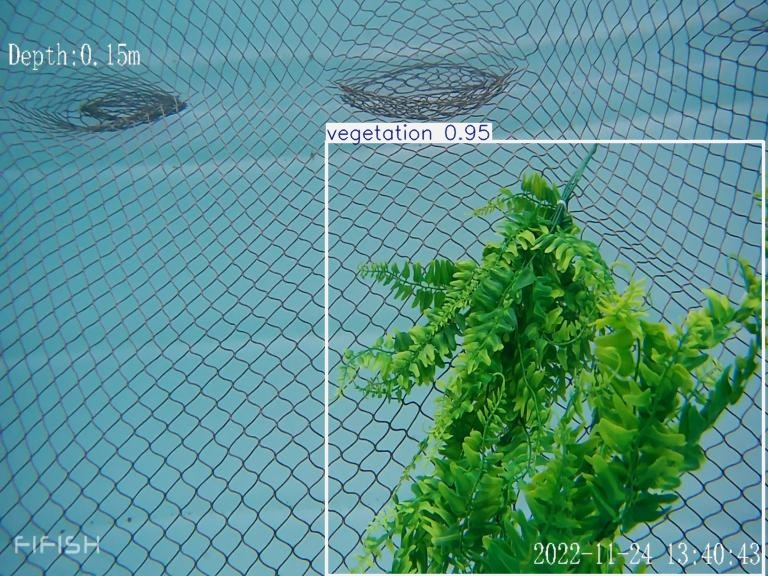

------------------------------------------------------------
image4.jpg


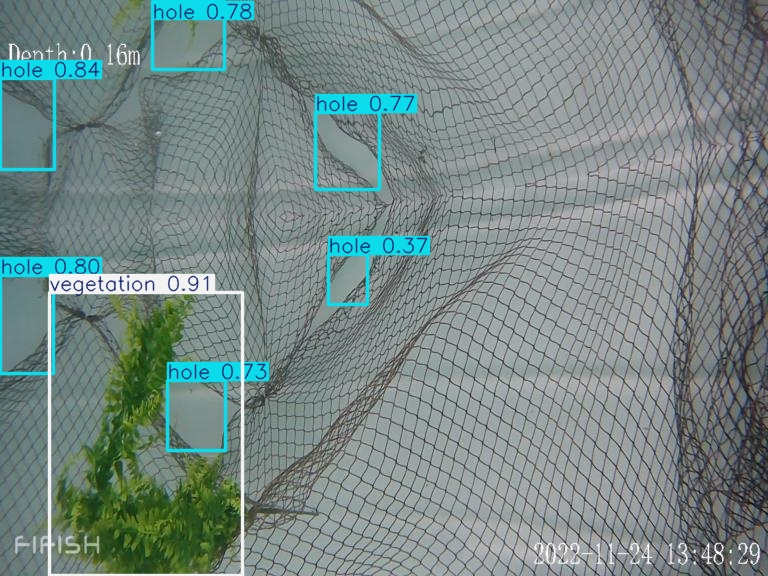

------------------------------------------------------------


In [ ]:
for img in predicted_images:
    print(os.path.basename(img))

    display(Image(filename=img))

    print("-"*60)

In [ ]:
pred_folder = hasil_prediksi

print("Folder prediksi:")
print(pred_folder)

Folder prediksi:
/content/runs/detect/predict


In [ ]:
precision = df.loc[best_epoch, "metrics/precision(B)"]
recall = df.loc[best_epoch, "metrics/recall(B)"]
map50 = df.loc[best_epoch, "metrics/mAP50(B)"]
map5095 = df.loc[best_epoch, "metrics/mAP50-95(B)"]

print("===== HASIL EVALUASI TEST =====")

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"mAP50     : {map50:.4f}")
print(f"mAP50-95  : {map5095:.4f}")

print("\nVisualisasi selesai.")

===== HASIL EVALUASI TEST =====
Precision : 0.9300
Recall    : 0.9133
mAP50     : 0.9618
mAP50-95  : 0.7434

Visualisasi selesai.


In [ ]:
pred_test = model.predict(
    source="/content/dataset/test/images",
    imgsz=640,
    conf=0.25,
    save=False,
    save_txt=True,
    save_conf=True,
    device=0,
    verbose=True
)


image 1/720 /content/dataset/test/images/1007_jpg.rf.5qtCWE4BQS5CrlC73OV0.jpg: 480x640 7 holes, 4 vegetations, 45.6ms
image 2/720 /content/dataset/test/images/1021_jpg.rf.YLW1o5hwO9qlV6jcM05F.jpg: 480x640 7 holes, 5 vegetations, 12.8ms
image 3/720 /content/dataset/test/images/102_jpg.rf.b9BNbOpDtdEO50JKSV1O.jpg: 480x640 8 holes, 3 vegetations, 12.8ms
image 4/720 /content/dataset/test/images/1034_jpg.rf.9AFhjvkNFiKj4x3punt7.jpg: 480x640 7 holes, 4 vegetations, 12.8ms
image 5/720 /content/dataset/test/images/104_jpg.rf.6isdSiqbN4RtH8u3NQZF.jpg: 480x640 8 holes, 4 vegetations, 12.8ms
image 6/720 /content/dataset/test/images/1054_jpg.rf.LcyR3TMBqISVcJUV7UUV.jpg: 480x640 9 holes, 4 vegetations, 12.8ms
image 7/720 /content/dataset/test/images/1065_jpg.rf.C9zOZRv4S4ABk2dBFIPr.jpg: 480x640 8 holes, 3 vegetations, 12.8ms
image 8/720 /content/dataset/test/images/106_jpg.rf.q3St2Mwgj3Oj61k7NgXZ.jpg: 480x640 8 holes, 5 vegetations, 12.1ms
image 9/720 /content/dataset/test/images/1093_jpg.rf.Yg51t

In [ ]:
predict_dir = pred_test[0].save_dir

print("Folder prediksi:")
print(predict_dir)

Folder prediksi:
/content/runs/detect/predict-2


In [ ]:
import os

gt_dir = "/content/dataset/test/labels"
pred_dir = os.path.join(predict_dir, "labels")

print("Ground Truth :", gt_dir)
print("Prediction   :", pred_dir)

Ground Truth : /content/dataset/test/labels
Prediction   : /content/runs/detect/predict-2/labels


In [ ]:
gt_files = sorted([
    f for f in os.listdir(gt_dir)
    if f.endswith(".txt")
])

pred_files = sorted([
    f for f in os.listdir(pred_dir)
    if f.endswith(".txt")
])

print("Ground truth :", len(gt_files))
print("Prediksi     :", len(pred_files))

Ground truth : 720
Prediksi     : 719


In [ ]:
gt_names = set(gt_files)
pred_names = set(pred_files)

missing = gt_names - pred_names

print("Jumlah gambar tanpa prediksi :", len(missing))

for f in sorted(missing):
    print(f)

Jumlah gambar tanpa prediksi : 1
frame2n (857)_jpg.rf.6QGlBENDIPmS78xpPv79.txt


In [ ]:
def polygon_to_bbox(points, width, height):
    """
    points : [x1,y1,x2,y2,...] normalisasi YOLO
    """

    xs = points[0::2]
    ys = points[1::2]

    xs = np.array(xs) * width
    ys = np.array(ys) * height

    xmin = xs.min()
    ymin = ys.min()
    xmax = xs.max()
    ymax = ys.max()

    return [xmin, ymin, xmax, ymax]

In [ ]:
def read_gt(label_path, width, height):

    gts = []

    with open(label_path, 'r') as f:
        lines = f.readlines()

    for line in lines:
        data = line.strip().split()

        cls = int(data[0])

        polygon = list(map(float, data[1:]))

        bbox = polygon_to_bbox(polygon, width, height)

        gts.append({
            'class': cls,
            'bbox': bbox
        })

    return gts

In [ ]:
def compute_iou(box1, box2):

    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])
    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter = max(0, xB-xA) * max(0, yB-yA)

    area1 = (box1[2]-box1[0]) * (box1[3]-box1[1])
    area2 = (box2[2]-box2[0]) * (box2[3]-box2[1])

    union = area1 + area2 - inter

    if union == 0:
        return 0

    return inter / union

In [ ]:
image_dir = "/content/dataset/images/test"
label_dir = "/content/dataset/labels/test"

iou_threshold = 0.5

TP = 0
FP = 0
FN = 0

results = []

In [ ]:
import cv2
image_dir = "/content/dataset/test/images"
label_dir = "/content/dataset/test/labels"

for image_name in os.listdir(image_dir):

    if not image_name.lower().endswith(('.jpg','.jpeg','.png')):
        continue

    image_path = os.path.join(image_dir, image_name)

    label_path = os.path.join(
        label_dir,
        os.path.splitext(image_name)[0] + ".txt"
    )

    image = cv2.imread(image_path)

    h, w = image.shape[:2]

    gt_boxes = read_gt(label_path, w, h)

    pred = model.predict(
        image,
        conf=0.25,
        verbose=False
    )[0]

    pred_boxes = []

    for box in pred.boxes:

        cls = int(box.cls.cpu().numpy()[0])

        xyxy = box.xyxy.cpu().numpy()[0]

        pred_boxes.append({
            'class': cls,
            'bbox': xyxy
        })

    matched_gt = set()

    for p in pred_boxes:

        best_iou = 0
        best_gt = -1

        for i, g in enumerate(gt_boxes):

            if i in matched_gt:
                continue

            if p['class'] != g['class']:
                continue

            iou = compute_iou(
                p['bbox'],
                g['bbox']
            )

            if iou > best_iou:
                best_iou = iou
                best_gt = i

        if best_iou >= iou_threshold:

            TP += 1
            matched_gt.add(best_gt)

            results.append([
                image_name,
                p['class'],
                best_iou,
                "TP"
            ])

        else:

            FP += 1

            results.append([
                image_name,
                p['class'],
                best_iou,
                "FP"
            ])

    FN += len(gt_boxes) - len(matched_gt)

Results saved to /content/runs/detect/predict-2
720 labels saved to /content/runs/detect/predict-2/labels
Results saved to /content/runs/detect/predict-2
720 labels saved to /content/runs/detect/predict-2/labels
Results saved to /content/runs/detect/predict-2
720 labels saved to /content/runs/detect/predict-2/labels
Results saved to /content/runs/detect/predict-2
720 labels saved to /content/runs/detect/predict-2/labels
Results saved to /content/runs/detect/predict-2
720 labels saved to /content/runs/detect/predict-2/labels
Results saved to /content/runs/detect/predict-2
720 labels saved to /content/runs/detect/predict-2/labels
Results saved to /content/runs/detect/predict-2
720 labels saved to /content/runs/detect/predict-2/labels
Results saved to /content/runs/detect/predict-2
720 labels saved to /content/runs/detect/predict-2/labels
Results saved to /content/runs/detect/predict-2
720 labels saved to /content/runs/detect/predict-2/labels
Results saved to /content/runs/detect/predict-

In [ ]:
precision = TP / (TP + FP) if (TP+FP)>0 else 0
recall = TP / (TP + FN) if (TP+FN)>0 else 0

f1 = (
    2 * precision * recall /
    (precision + recall)
    if (precision + recall)>0 else 0
)

print("===== HASIL EVALUASI =====")
print("TP :", TP)
print("FP :", FP)
print("FN :", FN)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

===== HASIL EVALUASI =====
TP : 2636
FP : 552
FN : 233
Precision : 0.8269
Recall    : 0.9188
F1-score  : 0.8704


In [ ]:
df = pd.DataFrame(
    results,
    columns=[
        "image",
        "class",
        "IoU",
        "status"
    ]
)

df.to_csv(
    "/content/hasil_evaluasi.csv",
    index=False
)

df.head()

,image,class,IoU,status
0,frame0-09-47-00_jpg.rf.yQu7k05nyLHLmur3XxCJ.jpg,0,0.971351,TP
1,frame0-06-52-50_jpg.rf.JiV5QJpcLnMYmi9bSiXG.jpg,0,0.990880,TP
2,1582_jpg.rf.qoccfKkSxECxKXxQkX48.jpg,2,0.821367,TP
3,1582_jpg.rf.qoccfKkSxECxKXxQkX48.jpg,1,0.912398,TP
4,1582_jpg.rf.qoccfKkSxECxKXxQkX48.jpg,1,0.918233,TP


In [ ]:
iou_list = []

In [ ]:
if best_iou >= iou_threshold:

    TP += 1
    matched_gt.add(best_gt)

    iou_list.append(best_iou)

    results.append([
        image_name,
        p['class'],
        best_iou,
        "TP"
    ])

In [ ]:
import numpy as np

mean_iou = np.mean(iou_list)

print("===== HASIL EVALUASI =====")
print("TP :", TP)
print("FP :", FP)
print("FN :", FN)

print(f"Mean IoU : {mean_iou:.4f}")
print(f"Mean IoU (%) : {mean_iou*100:.2f}%")

===== HASIL EVALUASI =====
TP : 2637
FP : 552
FN : 233
Mean IoU : 0.9817
Mean IoU (%) : 98.17%
